In [1]:
import os.path
import numpy as np
import time
import copy
import pickle

finalTR = 1.6

gaze_types = ['mocet', 'polynomial', 'linear', 'uncorrected']
subject_pool = {
                'sub-003':{'ses-07R':([1,2,3,4,5], False),
                           'ses-13R':([1,2,4,5,6], False)},
                'sub-004':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-005':{'ses-07':([1,2,3,4,5,6], True)},
                'sub-006':{'ses-07R':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-008':{'ses-07R':([2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-009':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,5,6], False)},
                'sub-010':{'ses-07':([1,2,3,4,5], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-011':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-012':{'ses-07':([1,2,4,5,6], False)},
                'sub-013':{'ses-07':([1,2,3,4], False)},
                'sub-014':{'ses-07':([2,3,4,5,6], False)},
                'sub-015':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-016':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-017':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5], False)},
                'sub-018':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-020':{'ses-07':([1,2,3,4,5,6], False),
                           'ses-13':([1,2,3,4,5,6], False)},
                'sub-021':{'ses-07':([1,2,4,5,6], False),
                           'ses-13':([1,2,4,5,6], False)},
                'sub-JJY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-KMY':{'ses-07':([1,2,3,4,5,6], False)},
                'sub-PJW':{'ses-07':([1,2,3,4,6], True)},
                'sub-PBJ':{'ses-07':([1,2,3,4,5], False)}
                }

task = 'task-mcHERDING'
method = 'linear'
testable_data = pickle.load(open('../testable_data_list.pkl', 'rb'))

subjects = []
for key in list(testable_data.keys()):
    subjects.append(key[0])
subjects = list(set(subjects))
subjects.sort()

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel, sem
import pickle

gaze_types = ['mocet', 'polynomial', 'linear', 'uncorrected']
with open('data/next_target_distance.pkl', 'rb') as f:
    next_target_distance = pickle.load(f)

for gaze_type in gaze_types:
    next_target_distance[gaze_type] = np.array(next_target_distance[gaze_type]) * 100

TtestResult(statistic=7.150746823704128, pvalue=8.510351040821499e-07, df=19)
TtestResult(statistic=8.01770151503548, pvalue=1.6218034965032983e-07, df=19)
TtestResult(statistic=10.362292236725192, pvalue=2.957650057794594e-09, df=19)
0.035395277230445


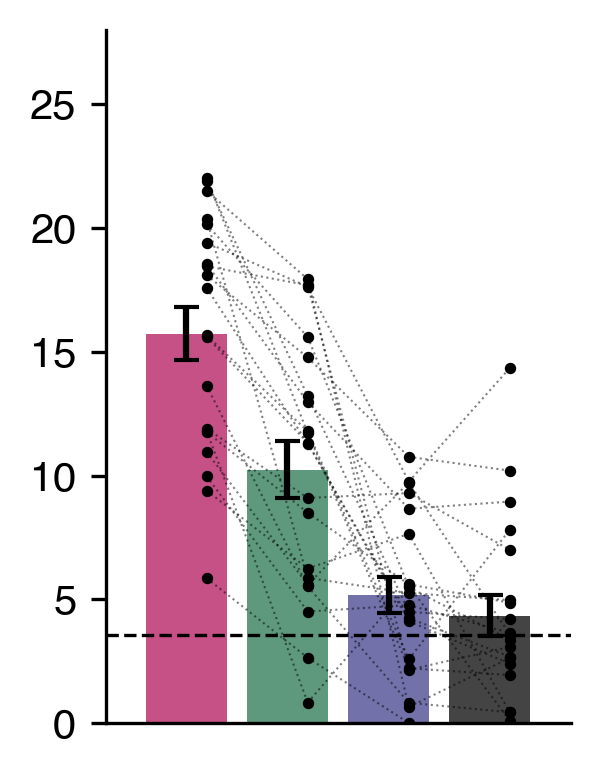

In [26]:


plt.style.use('default')
fig, axes = plt.subplots(1,1, sharey=True, sharex=True, figsize=(2,3), dpi=300)
color_list = ['#c55187','#5e997d', '#7371a9', '#444444']

print(ttest_rel(next_target_distance['mocet'], next_target_distance['polynomial']))
print(ttest_rel(next_target_distance['mocet'], next_target_distance['linear']))
print(ttest_rel(next_target_distance['mocet'], next_target_distance['uncorrected']))
#print(roi_name, ttest_rel(angle_statistics[roi_name]['mocet-6'], angle_statistics[roi_name]['uncorrected']))
axes.bar([0,1,2,3], [np.mean(next_target_distance['mocet']),
                        np.mean(next_target_distance['polynomial']),
                        np.mean(next_target_distance['linear']),
                        np.mean(next_target_distance['uncorrected']),
                        ], 
              yerr= [sem(next_target_distance['mocet']),
                        sem(next_target_distance['polynomial']),
                        sem(next_target_distance['linear']),
                        sem(next_target_distance['uncorrected']),
                        ], color = color_list, capsize=3)
#axes.axhline(90, c='#777777', linestyle=":", lw=0.8)
for t, tag in enumerate(gaze_types):
    axes.scatter(t*np.ones(len(subjects))+0.2, next_target_distance[tag], s=3, c='k')
for s, subject in enumerate(subjects):
    axes.plot([0+0.2, 1+0.2], [next_target_distance['mocet'][s], next_target_distance['polynomial'][s]],
                   c='k', alpha=0.5, lw=0.5, linestyle=':')
    axes.plot([1+0.2, 2+0.2], [next_target_distance['polynomial'][s], next_target_distance['linear'][s]],
                   c='k', alpha=0.5, lw=0.5, linestyle=':')
    axes.plot([2+0.2, 3+0.2], [next_target_distance['linear'][s], next_target_distance['uncorrected'][s]],
                   c='k', alpha=0.5, lw=0.5, linestyle=':')
    
area = 1800 * 1200
hit_area = np.pi * (78*2)**2
print(hit_area / area)
axes.axhline(100*hit_area/area, c='k', lw=0.8, linestyle='--')
axes.set_ylim(0.0, 28)
axes.set_xlim(-0.8, 3.8)
axes.set_xticks([0,1,2,3])
axes.set_xticks([])
axes.set_xticklabels([])
axes.spines[['right', 'top']].set_visible(False)
plt.subplots_adjust(wspace=0.08)


for tick in axes.get_yticklabels():
    tick.set_fontname("Helvetica")
for tick in axes.get_xticklabels():
    tick.set_fontname("Helvetica")
    